Тема:
«Исследование и сравнение методов понижения размерности и кластеризации на реальном высокоразмерном датасете (из области по выбору: биоинформатика, тексты, изображения, графы) с анализом устойчивости и интерпретируемости полученных кластеров».

Датасет: 20 Newsgroups (реальный корпус текстов). После преобразования в TF‑IDF пространство размерность достигает 10 000–15 000 признаков, что делает его подходящим для исследования методов снижения размерности.

Основные требования к проекту:
Выбор и обоснование одного или двух реальных высокоразмерных датасетов (например, single‑cell RNA‑seq, embedding‑представления текстов, feature‑описания изображений).
Построение и сравнение нескольких пайплайнов «DR → кластеризация» (минимум 3 DR‑метода и 3 алгоритма кластеризации) с оценкой качества, устойчивости и практической интерпретации кластеров.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
import umap

from itertools import product
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)

from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

import warnings
warnings.filterwarnings("ignore")

## Загрузка датасета

In [2]:
newsgroups = fetch_20newsgroups(
    subset='all',
    remove=('headers','footers','quotes')
)

texts = newsgroups.data
true_labels = newsgroups.target

print("Количество документов:", len(texts))

Количество документов: 18846


## Преобразование текста в высокоразмерное пространство

In [3]:
vectorizer = TfidfVectorizer(
    max_features=15000,
    stop_words='english'
)

X = vectorizer.fit_transform(texts)

print("Размерность TF-IDF:", X.shape)

Размерность TF-IDF: (18846, 15000)


## Методы понижения размерности

Используем 4 метода DR:

- PCA
- Truncated SVD (LSA)
- t-SNE
- UMAP

In [4]:
# PCA
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X.toarray())

# Truncated SVD
svd = TruncatedSVD(n_components=50)
X_svd = svd.fit_transform(X)

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_svd)

# UMAP
umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_svd)

Визуализация результатов DR

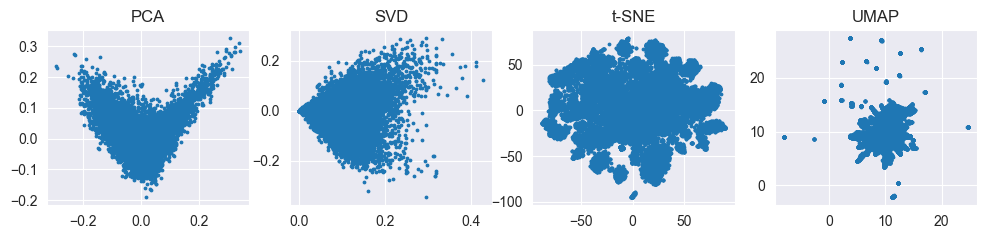

In [5]:
plt.figure(figsize=(12,5))

plt.subplot(2,4,1)
plt.scatter(X_pca[:,0], X_pca[:,1], s=3)
plt.title("PCA")

plt.subplot(2,4,2)
plt.scatter(X_svd[:,0], X_svd[:,1], s=3)
plt.title("SVD")

plt.subplot(2,4,3)
plt.scatter(X_tsne[:,0], X_tsne[:,1], s=3)
plt.title("t-SNE")

plt.subplot(2,4,4)
plt.scatter(X_umap[:,0], X_umap[:,1], s=3)
plt.title("UMAP")

plt.show()

## Алгоритмы кластеризации

Используем 3 различных алгоритма:

- KMeans
- Agglomerative Clustering
- DBSCAN

In [6]:
kmeans = KMeans(n_clusters=20, random_state=42)
labels_kmeans = kmeans.fit_predict(X_svd)

agg = AgglomerativeClustering(n_clusters=20)
labels_agg = agg.fit_predict(X_svd)

dbscan = DBSCAN(eps=0.3, min_samples=5)
labels_db = dbscan.fit_predict(X_svd)

## Метрики качества кластеризации

Используем несколько метрик:

- Silhouette Score
- Davies‑Bouldin Index
- Calinski‑Harabasz Index

In [7]:
def evaluate(X, labels):

    mask = labels != -1

    if len(np.unique(labels[mask])) < 2:
        return None

    return {
        "silhouette": silhouette_score(X[mask], labels[mask]),
        "davies_bouldin": davies_bouldin_score(X[mask], labels[mask]),
        "calinski_harabasz": calinski_harabasz_score(X[mask], labels[mask])
    }

results = {}

results['KMeans'] = evaluate(X_svd, labels_kmeans)
results['Agglomerative'] = evaluate(X_svd, labels_agg)
results['DBSCAN'] = evaluate(X_svd, labels_db)

pd.DataFrame(results)

,KMeans,Agglomerative,DBSCAN
silhouette,0.086729,0.049158,None
davies_bouldin,2.266970,2.359219,None
calinski_harabasz,479.876572,415.956467,None


## Сравнение

In [8]:
DR_methods = {
    "PCA": X_pca,
    "SVD": X_svd,
    "TSNE": X_tsne,
    "UMAP": X_umap,
}

clustering_methods = {
    "KMeans": kmeans,
    "Agglomerative": agg,
    "DBSCAN": dbscan
}

pipeline_results = []

for dr_name, cluster_name in product(DR_methods, clustering_methods):

    X_data = DR_methods[dr_name]

    model = clustering_methods[cluster_name]

    labels = model.fit_predict(X_data)

    scores = evaluate(X_data, labels)

    if scores:

        scores["DR"] = dr_name
        scores["Clustering"] = cluster_name
        scores["Pipeline"] = f"{dr_name} + {cluster_name}"

        pipeline_results.append(scores)

results_df = pd.DataFrame(pipeline_results)

results_df

,silhouette,davies_bouldin,calinski_harabasz,DR,Clustering,Pipeline
0,0.088885,2.130998,497.194279,PCA,KMeans,PCA + KMeans
1,0.075344,2.362641,408.757225,PCA,Agglomerative,PCA + Agglomerative
2,0.086729,2.266970,479.876572,SVD,KMeans,SVD + KMeans
3,0.049158,2.359219,415.956467,SVD,Agglomerative,SVD + Agglomerative
4,0.386954,0.787144,18276.410156,TSNE,KMeans,TSNE + KMeans
5,0.342867,0.843078,15797.122070,TSNE,Agglomerative,TSNE + Agglomerative
6,0.746326,0.321307,102847.726562,TSNE,DBSCAN,TSNE + DBSCAN
7,0.398373,0.703365,13025.287109,UMAP,KMeans,UMAP + KMeans
8,0.377489,0.708379,12891.750977,UMAP,Agglomerative,UMAP + Agglomerative
9,0.003066,0.340461,436.327118,UMAP,DBSCAN,UMAP + DBSCAN


In [9]:
results_df.sort_values("silhouette", ascending=False)

,silhouette,davies_bouldin,calinski_harabasz,DR,Clustering,Pipeline
6,0.746326,0.321307,102847.726562,TSNE,DBSCAN,TSNE + DBSCAN
7,0.398373,0.703365,13025.287109,UMAP,KMeans,UMAP + KMeans
4,0.386954,0.787144,18276.410156,TSNE,KMeans,TSNE + KMeans
8,0.377489,0.708379,12891.750977,UMAP,Agglomerative,UMAP + Agglomerative
5,0.342867,0.843078,15797.122070,TSNE,Agglomerative,TSNE + Agglomerative
0,0.088885,2.130998,497.194279,PCA,KMeans,PCA + KMeans
2,0.086729,2.266970,479.876572,SVD,KMeans,SVD + KMeans
1,0.075344,2.362641,408.757225,PCA,Agglomerative,PCA + Agglomerative
3,0.049158,2.359219,415.956467,SVD,Agglomerative,SVD + Agglomerative
9,0.003066,0.340461,436.327118,UMAP,DBSCAN,UMAP + DBSCAN


#### Лучшие метрики показывает DBSCAN с уменьшением размерности через TSNE.

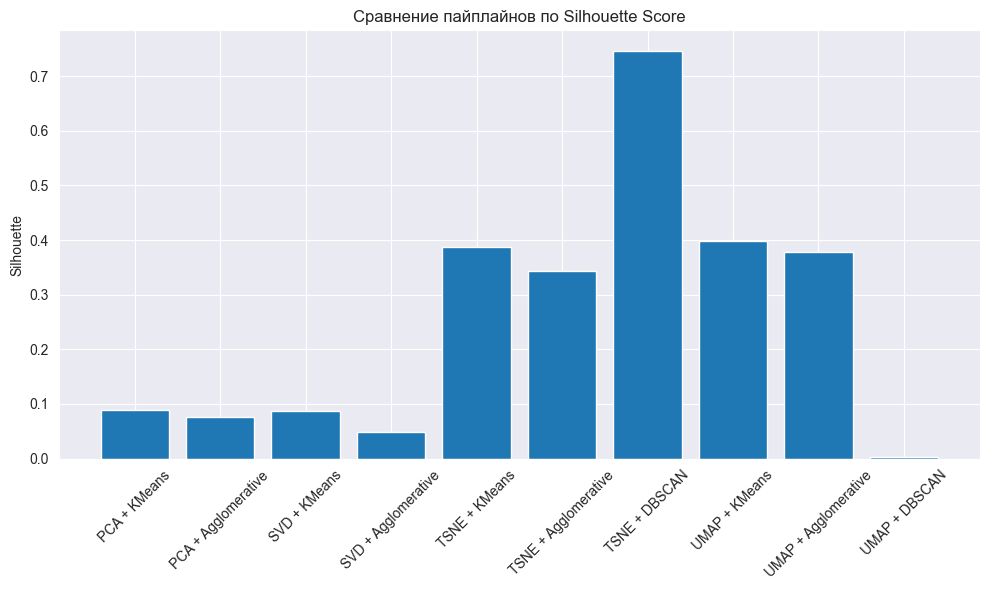

In [10]:
plt.figure(figsize=(10,6))

plt.bar(results_df["Pipeline"], results_df["silhouette"])

plt.xticks(rotation=45)

plt.title("Сравнение пайплайнов по Silhouette Score")

plt.ylabel("Silhouette")

plt.tight_layout()

plt.show()

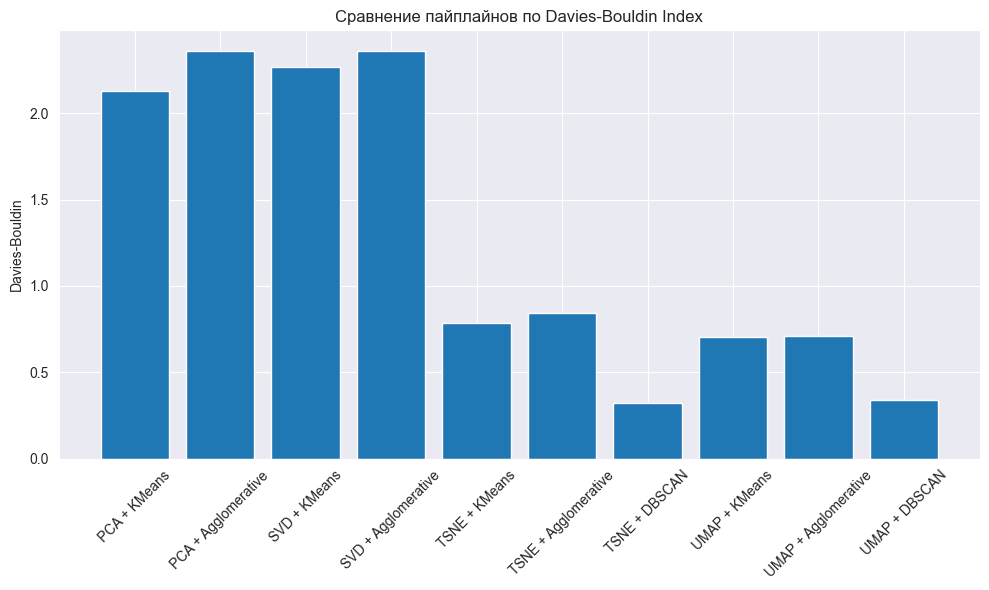

In [11]:
plt.figure(figsize=(10,6))

plt.bar(results_df["Pipeline"], results_df["davies_bouldin"])

plt.xticks(rotation=45)

plt.title("Сравнение пайплайнов по Davies-Bouldin Index")

plt.ylabel("Davies-Bouldin")

plt.tight_layout()

plt.show()

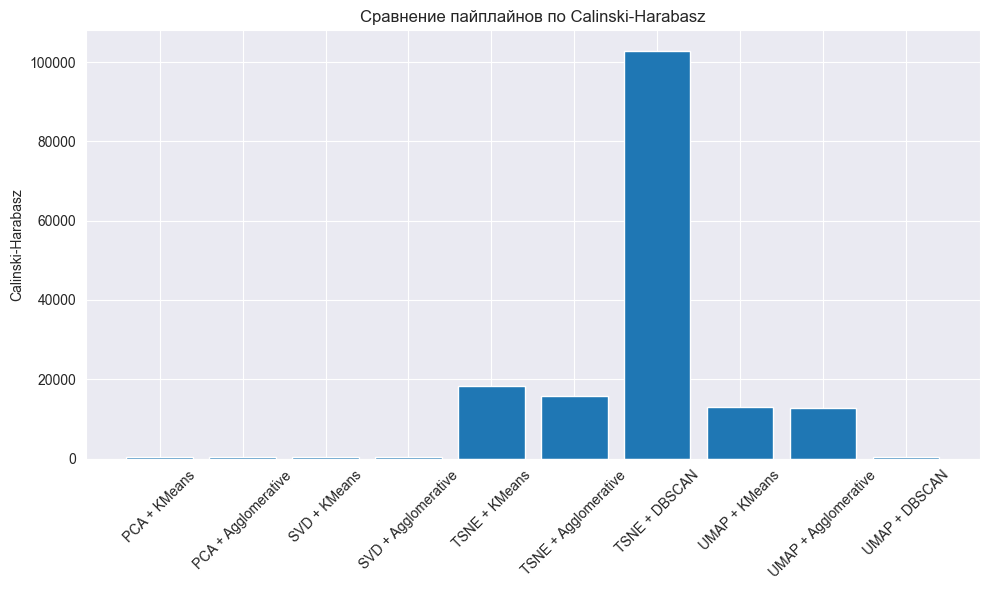

In [12]:
plt.figure(figsize=(10,6))

plt.bar(results_df["Pipeline"], results_df["calinski_harabasz"])

plt.xticks(rotation=45)

plt.title("Сравнение пайплайнов по Calinski-Harabasz")

plt.ylabel("Calinski-Harabasz")

plt.tight_layout()

plt.show()

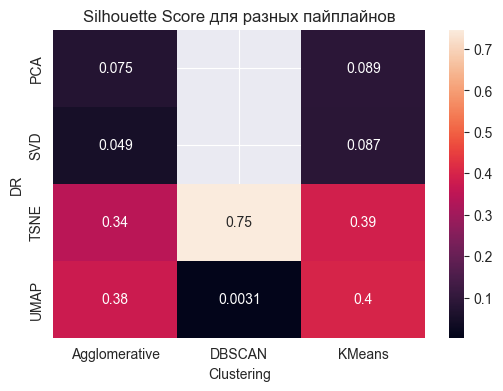

In [13]:
pivot = results_df.pivot(index="DR", columns="Clustering", values="silhouette")

plt.figure(figsize=(6,4))

sns.heatmap(pivot, annot=True)

plt.title("Silhouette Score для разных пайплайнов")

plt.show()

## Анализ устойчивости кластеризации

Проверяем устойчивость результатов с помощью bootstrap‑подвыборок.

In [15]:
for name, base_model in clustering_methods.items():
    stability_scores = []

    for i in range(10):
        sample = resample(X_svd, n_samples=5000)

        if name == "GMM":
            labels = base_model.fit(sample).predict(sample)
        else:
            labels = base_model.fit_predict(sample)

        if len(set(labels)) > 1 and len(set(labels)) < len(sample):
            score = silhouette_score(sample, labels)
            stability_scores.append(score)

    results[name] = (
        np.mean(stability_scores),
        np.std(stability_scores)
    )

for k, v in results.items():
    print(k)
    print("Средняя устойчивость:", v[0])
    print("Std:", v[1])
    print()

KMeans
Средняя устойчивость: 0.08819152766432589
Std: 0.006820213080949649

Agglomerative
Средняя устойчивость: 0.07210156823700536
Std: 0.016105646967567062

DBSCAN
Средняя устойчивость: 0.6128914296783147
Std: 0.02242935080869027



## Интерпретация кластеров

In [16]:
terms = vectorizer.get_feature_names_out()

centroids = kmeans.cluster_centers_

for i in range(10):

    order = centroids[i].argsort()[-10:]

    words = [terms[j] for j in order]

    print(f"Cluster {i}:", words)

Cluster 0: ['01', '0g', '040', '030', '04', '0666', '0_', '05pm', '000', '00']
Cluster 1: ['0v', '08', '01', '0m', '0_', '0d', '07', '0h', '03', '00']
Cluster 2: ['04', '08', '03', '02106', '005', '0_', '001', '00', '000', '000iu']
Cluster 3: ['0k', '09', '05', '04', '02', '0d', '0c', '01', '00', '001']
Cluster 4: ['0m', '0c', '0n', '071', '0h', '001', '0b', '000iu', '000', '00']
Cluster 5: ['071', '09', '0l', '03', '0c', '06', '07', '04', '00', '02106']
Cluster 6: ['0i', '0j', '0n', '06', '0d', '0444', '00pm', '05pm', '000iu', '00']
Cluster 7: ['08', '0i', '05pm', '005', '02', '0c', '06', '0666', '040', '00']
Cluster 8: ['05', '02', '00pm', '071', '0444', '09', '01', '040', '000', '00']
Cluster 9: ['0r', '0x', '0q', '05pm', '0u', '05', '07', '03', '0666', '00']


Визуализация кластеров

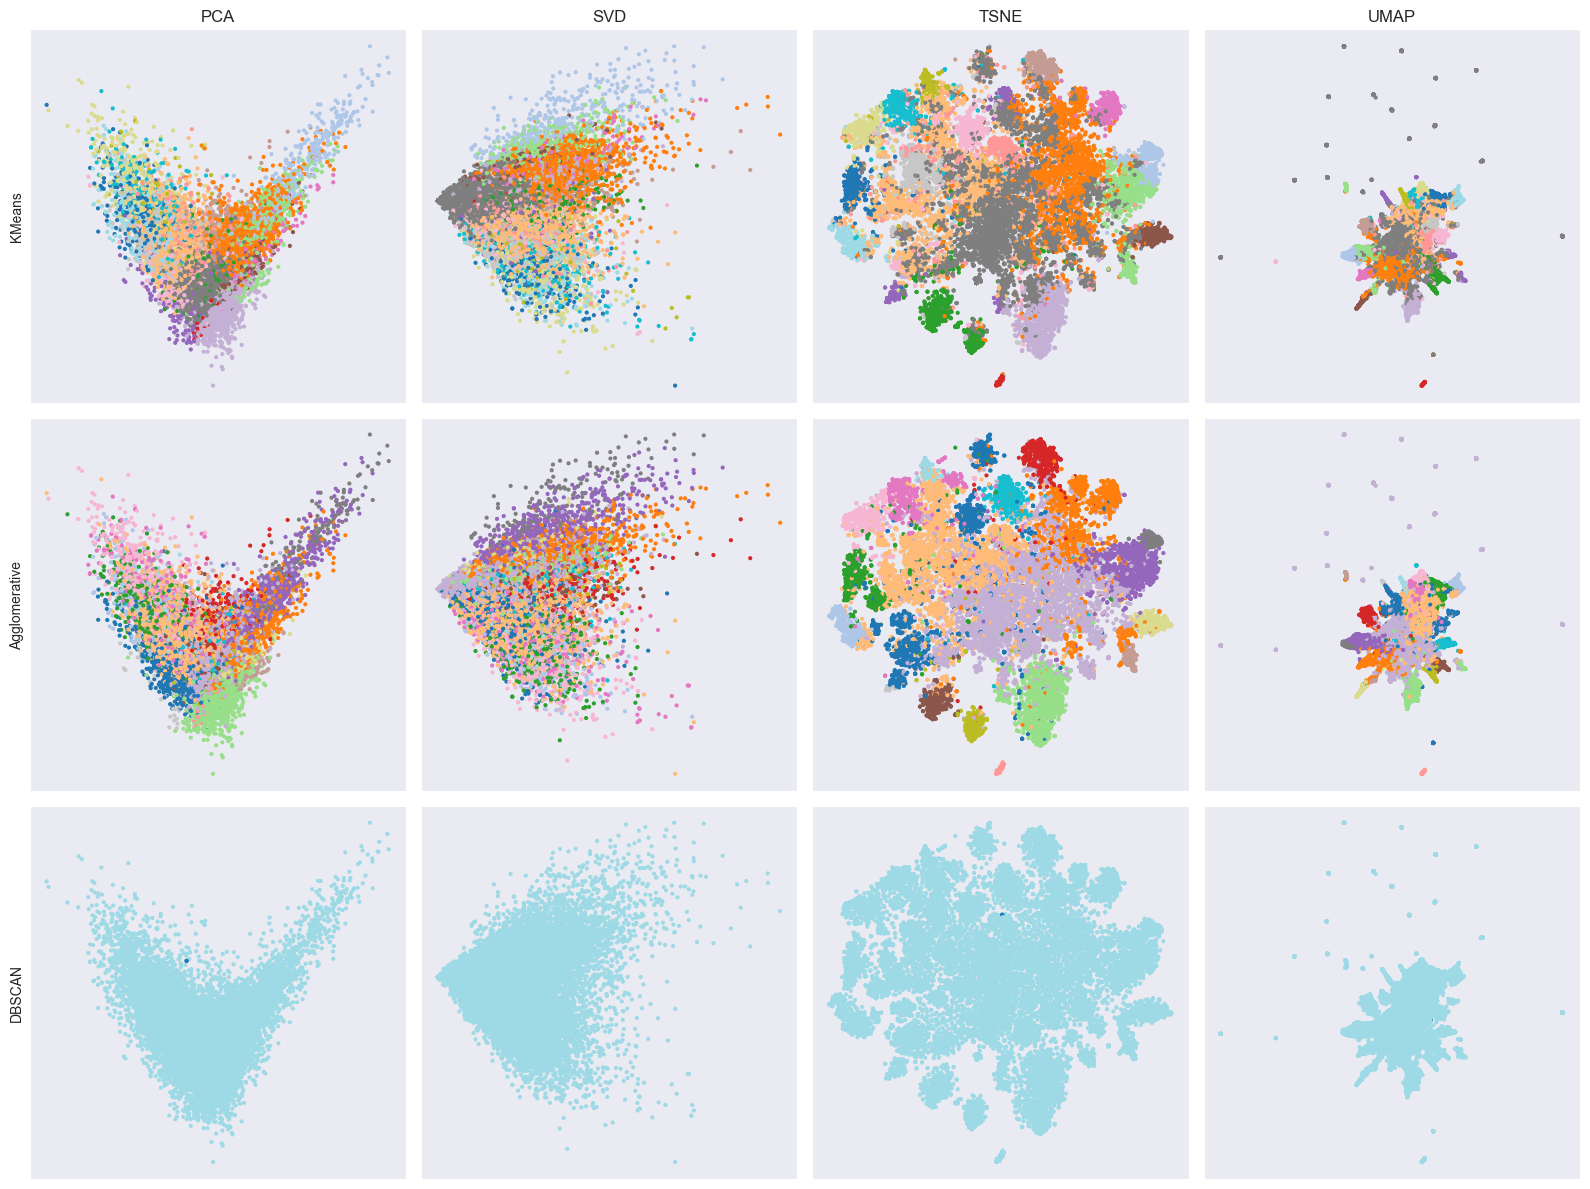

In [18]:
methods_labels = {
    "KMeans": labels_kmeans,
    "Agglomerative": labels_agg,
    "DBSCAN": labels_db
}

fig, axes = plt.subplots(
    len(methods_labels),
    len(DR_methods),
    figsize=(4 * len(DR_methods), 4 * len(methods_labels))
)

for i, (c_name, labels) in enumerate(methods_labels.items()):
    for j, (p_name, X_proj) in enumerate(DR_methods.items()):

        ax = axes[i, j]

        ax.scatter(
            X_proj[:, 0],
            X_proj[:, 1],
            c=labels,
            s=4,
            cmap="tab20"
        )

        if i == 0:
            ax.set_title(p_name)

        if j == 0:
            ax.set_ylabel(c_name)

        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

Итоговая таблица сравнения

In [21]:
results_df.sort_values("silhouette", ascending=False)

,silhouette,davies_bouldin,calinski_harabasz,DR,Clustering,Pipeline
6,0.746326,0.321307,102847.726562,TSNE,DBSCAN,TSNE + DBSCAN
7,0.398373,0.703365,13025.287109,UMAP,KMeans,UMAP + KMeans
4,0.386954,0.787144,18276.410156,TSNE,KMeans,TSNE + KMeans
8,0.377489,0.708379,12891.750977,UMAP,Agglomerative,UMAP + Agglomerative
5,0.342867,0.843078,15797.122070,TSNE,Agglomerative,TSNE + Agglomerative
0,0.088885,2.130998,497.194279,PCA,KMeans,PCA + KMeans
2,0.086729,2.266970,479.876572,SVD,KMeans,SVD + KMeans
1,0.075344,2.362641,408.757225,PCA,Agglomerative,PCA + Agglomerative
3,0.049158,2.359219,415.956467,SVD,Agglomerative,SVD + Agglomerative
9,0.003066,0.340461,436.327118,UMAP,DBSCAN,UMAP + DBSCAN


DBSCAN плохо разделил выборку на кластеры, хоть и имеет более высокие метрики. Однако мы учитываем, что они иногда плохо оценивают DBSCAN в таких ситуациях.

В свою очередь методы KMeans и Agglomerative показывают лучше разделение.